In [12]:
import pandas as pd
file_path = "ai_student_impact_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [13]:
#checking for data types
print("--DATA TYPES--")
df.info()

# check how many missing (blank) values
print("\n-- MISSING VALUES --")
print(df.isnull().sum())

--DATA TYPES--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GP

In [14]:
#check for any duplicate rows and remove them
df = df.drop_duplicates()

In [15]:
#Feature engineering : Create a GPA_change column
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

#Lets look at the average GPA change based on Burnout Risk
print(" ---Average GPA Change by burnout risk --- ")
print(df.groupby('Burnout_Risk_Level')['GPA_Change'].mean())

#Save clean data to a new file so we don't have to do this again
df.to_csv("ai_impact_cleaned.csv",index=False)
print("\n Success! Clean data saved as 'ai_impact_cleaned.csv' ")

 ---Average GPA Change by burnout risk --- 
Burnout_Risk_Level
High      0.195644
Low       0.200381
Medium    0.209838
Name: GPA_Change, dtype: float64

 Success! Clean data saved as 'ai_impact_cleaned.csv' 


In [16]:
#Phase 3 EDA
print("-- PIVOT TABLE 1: How does the AI Use Case affect GPA? --")
# Does using AI for 'Writing' vs 'Math' change your GPA differently?
pivot1 = pd.pivot_table(
    df,
    values='GPA_Change',
    index='Primary_Use_Case',
    aggfunc='mean'
).sort_values(by='GPA_Change',ascending=False)

print(pivot1)

print("\n\n -- PIVOT TABLE 2: Which Majors rely on AI the most? --")
#Which # Does using AI for 'Writing' vs 'Math' change your GPA differently?
pivot2 = pd.pivot_table(
    df,
    values='Weekly_GenAI_Hours',
    index='Major_Category',
    aggfunc='mean'
).sort_values(by='Weekly_GenAI_Hours', ascending=False)
print(pivot2)


-- PIVOT TABLE 1: How does the AI Use Case affect GPA? --
                           GPA_Change
Primary_Use_Case                     
Debugging/Troubleshooting    0.249128
Copywriting/Drafting         0.200426
Ideation                     0.199942
Summarizing_Reading          0.196886
Direct_Answer_Generation     0.133473


 -- PIVOT TABLE 2: Which Majors rely on AI the most? --
                Weekly_GenAI_Hours
Major_Category                    
STEM                     10.488609
Business                  8.275898
Medical                   7.546728
Arts                      7.271702
Humanities                6.770144


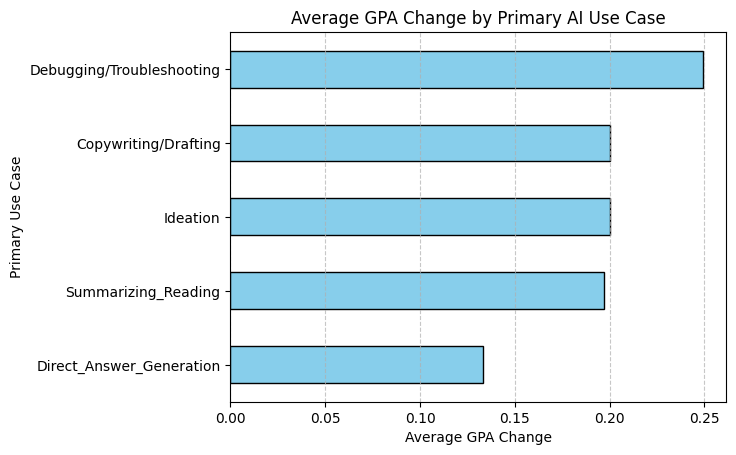

/tmp/ipykernel_12465/3748188118.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pivot2_df, x='Major_Category', y='Weekly_GenAI_Hours', palette='viridis')


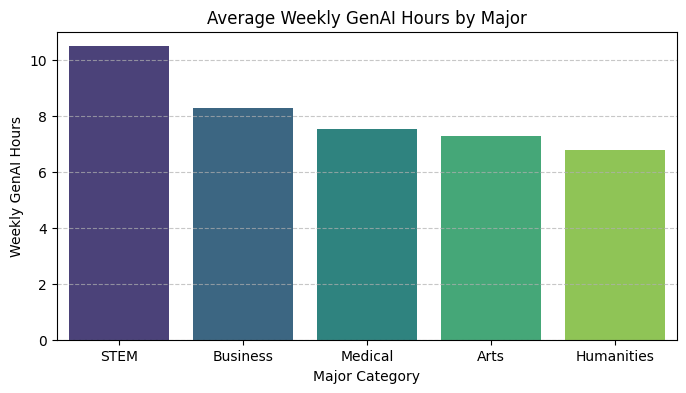

In [17]:

import matplotlib.pyplot as plt

# Plot a horizontal bar chart for Pivot 1
pivot1.plot(kind='barh', legend=False, color='skyblue', edgecolor='black')

plt.title('Average GPA Change by Primary AI Use Case')
plt.xlabel('Average GPA Change')
plt.ylabel('Primary Use Case')
plt.gca().invert_yaxis()  # Keeps the highest GPA change at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


import seaborn as sns

# Reset index to convert the pivot table index back into a column for Seaborn
pivot2_df = pivot2.reset_index()

# Plot using Seaborn
plt.figure(figsize=(8, 4))
sns.barplot(data=pivot2_df, x='Major_Category', y='Weekly_GenAI_Hours', palette='viridis')

plt.title('Average Weekly GenAI Hours by Major')
plt.xlabel('Major Category')
plt.ylabel('Weekly GenAI Hours')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
import sqlite3

# 1. Create a connection to a brand new SQL database (it creates this file automatically)
conn = sqlite3.connect('ai_students.db')

# 2. Push our clean Pandas DataFrame into a new SQL table called 'Student_Records'
df.to_sql('Student_Records', conn, if_exists='replace', index=False)
print("--- Database created and data loaded! ---\n")

# 3. Write a standard SQL query (Let's find the average anxiety level for heavy AI users)
query = """
    SELECT Major_Category, AVG(Anxiety_Level_During_Exams) as Avg_Anxiety
    FROM Student_Records
    WHERE Perceived_AI_Dependency > 3
    GROUP BY Major_Category
    ORDER BY Avg_Anxiety DESC;
"""

# 4. Run the SQL query and print the results
sql_results = pd.read_sql_query(query, conn)
print("--- SQL QUERY RESULTS: Anxiety Levels of Highly Dependent AI Users ---")
print(sql_results)


--- Database created and data loaded! ---

--- SQL QUERY RESULTS: Anxiety Levels of Highly Dependent AI Users ---
  Major_Category  Avg_Anxiety
0           STEM     4.986529
1       Business     4.780128
2        Medical     4.775162
3           Arts     4.728729
4     Humanities     4.693529
